# NFL Salary Cap Analysis

GitHub Repo: https://github.com/zagold03/DSCI-235-Final-Project.git

## Authors
- Zach Goldstein

## Introduction

In the NFL, teams must operate under a salary cap, which limits how much they can spend on players. 
A player's CapHit represents how much of their contract counts against the team’s salary cap.

This project analyzes how NFL teams allocate their salary cap across players. 
We focus on how position, experience, and player characteristics relate to salary cap hits.

Key questions include:
- How is cap space distributed across positions?
- Do more experienced players earn higher cap hits?
- How do teams differ in their spending strategies?

In [6]:
# loading in the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/zagold03/DSCI-235-Final-Project/main/Master-Player-List.csv"
df = pd.read_csv(url)
df.head()

,PlayerID,Name,Team,Position,Height,Weight,DOB,Age,YrsExp,CapHit
0,ABrewerARI,Aaron Brewer,ARI,LS,6-5,232,7/5/1990,34,13,"$1,152,500"
1,ABaccelliaARI,Andre Baccellia,ARI,WR,5-10,175,1/7/1997,27,2,"$985,000"
2,AChachereARI,Andre Chachere,ARI,DB,6-0,197,2/10/1996,28,4,"$1,055,000"
3,APleasantsARI,Austen Pleasants,ARI,OT,6-7,330,8/22/1997,26,1,"$795,000"
4,BOjulariARI,B.J. Ojulari,ARI,LB,6-2,248,4/5/2002,22,2,"$1,954,003"


### Cleaning

In [9]:
# inspect column names
df.columns

Index(['PlayerID', 'Name', 'Team', 'Position', 'Height', 'Weight', 'DOB',
       'Age', 'YrsExp', 'CapHit'],
      dtype='object')

In [11]:
# clean CapHit: remove $ and commas, then convert to numeric
df['CapHit'] = (
    df['CapHit']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['CapHit'] = pd.to_numeric(df['CapHit'], errors='coerce')

# drop rows with missing cap hit
df = df.dropna(subset=['CapHit'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2846 entries, 0 to 2845
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   PlayerID  2846 non-null   object
 1   Name      2846 non-null   object
 2   Team      2846 non-null   object
 3   Position  2846 non-null   object
 4   Height    2846 non-null   object
 5   Weight    2846 non-null   int64 
 6   DOB       2846 non-null   object
 7   Age       2846 non-null   int64 
 8   YrsExp    2846 non-null   object
 9   CapHit    2846 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 222.5+ KB


In [13]:
# extra check
df[['Name', 'Team', 'Position', 'CapHit']].head()

,Name,Team,Position,CapHit
0,Aaron Brewer,ARI,LS,1152500
1,Andre Baccellia,ARI,WR,985000
2,Andre Chachere,ARI,DB,1055000
3,Austen Pleasants,ARI,OT,795000
4,B.J. Ojulari,ARI,LB,1954003


### Basic Exploration

In [16]:
df.describe()

,Weight,Age,CapHit
count,2846.000000,2846.000000,2.846000e+03
mean,242.809557,25.587491,2.720630e+06
std,47.547807,2.903347,4.688589e+06
min,153.000000,20.000000,0.000000e+00
25%,202.000000,24.000000,8.733672e+05
50%,231.000000,25.000000,1.045108e+06
75%,290.000000,27.000000,2.281765e+06
max,380.000000,40.000000,6.377468e+07


In [18]:
# average cap hit
df['CapHit'].mean()

2720630.247364722

### Cap Hit by Position

In [25]:
pos_salary = df.groupby('Position')['CapHit'].mean().sort_values()

pos_salary

Position
OL     8.579112e+05
DL     8.922692e+05
LS     1.143052e+06
DB     1.483239e+06
RB     1.705040e+06
SAF    1.745119e+06
P      1.792170e+06
LB     1.985671e+06
TE     2.144300e+06
FB     2.290181e+06
CB     2.410495e+06
C      2.447746e+06
K      2.534668e+06
WR     2.694527e+06
DT     2.873022e+06
OG     2.876539e+06
DE     3.244449e+06
OT     3.651199e+06
SS     4.594868e+06
ILB    4.968417e+06
MLB    5.922936e+06
QB     6.911429e+06
FS     7.226101e+06
NT     7.356394e+06
OLB    9.743073e+06
Name: CapHit, dtype: float64

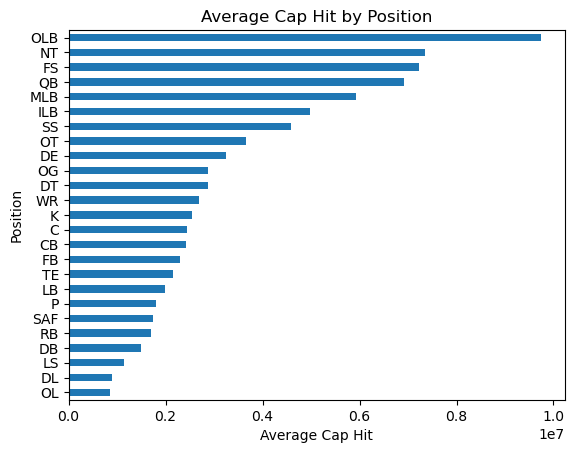

In [27]:
# plotting
pos_salary.plot(kind='barh')
plt.title('Average Cap Hit by Position')
plt.xlabel('Average Cap Hit')
plt.ylabel('Position')
plt.show()

#### Analysis
- This plot shows that certain defensive positions, such as OLB and NT, have the highest average cap hits in this dataset, even exceeding quarterbacks.
- While quarterbacks are generally expected to be among the highest-paid positions, this result suggests that high-value defensive roles are also heavily compensated.
- Positions like offensive line (OL), defensive line (DL), and long snapper (LS) have much lower average cap hits.
- Overall, this highlights that salary distribution varies significantly by position and is not limited to just traditionally high-profile roles.

### Cap Hit by Experience

In [34]:
# fix YrsExp properly
df['YrsExp'] = df['YrsExp'].replace('R', 0)   # sometimes it's "R" not "Rook"
df['YrsExp'] = pd.to_numeric(df['YrsExp'], errors='coerce')

# drop any remaining bad values
df = df.dropna(subset=['YrsExp'])

In [36]:
exp_salary = df.groupby('YrsExp')['CapHit'].mean()

exp_salary

YrsExp
0     9.736330e+05
1     8.232275e+05
2     1.271973e+06
3     1.520888e+06
4     2.296649e+06
5     3.583499e+06
6     5.620185e+06
7     6.186757e+06
8     7.504232e+06
9     7.051626e+06
10    4.659993e+06
11    9.687686e+06
12    8.418285e+06
13    5.603811e+06
14    1.034658e+07
15    8.322202e+06
16    2.577500e+07
17    2.302500e+06
18    4.875000e+06
19    2.000000e+06
20    1.716111e+07
Name: CapHit, dtype: float64

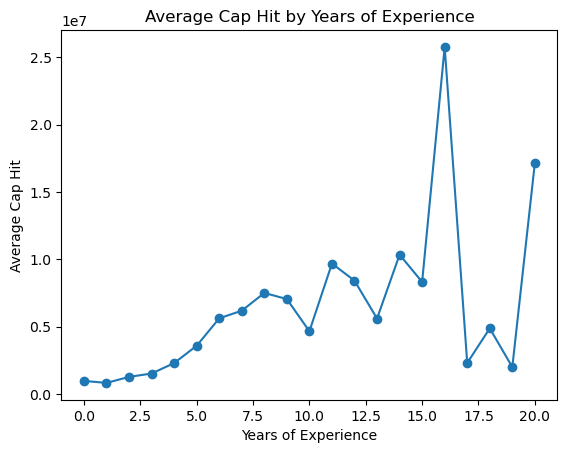

In [38]:
# plotting
exp_salary.plot(marker='o')
plt.title('Average Cap Hit by Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Average Cap Hit')
plt.show()

#### Analysis
- Average cap hit increases steadily from rookie years through mid-career, showing that players tend to earn more as they gain experience.
- There is a sharp spike around 15–16 years of experience, likely driven by a small number of very high-paid veteran players.
- After this peak, cap hits drop significantly, suggesting that most players do not maintain top salaries late in their careers.
- Overall, experience is positively related to salary, but the relationship is uneven due to outliers and a smaller number of long-tenured players.

### Team Level Analysis

In [43]:
team_salary = df.groupby('Team')['CapHit'].sum().sort_values()

team_salary

Team
MIN    210241609
TB     212253449
PHI    215736895
DEN    216348306
BUF    218613299
LAC    219428618
NYJ    220453035
GB     221120063
DET    225379050
LV     226005047
WAS    228664370
TEN    229360879
NE     234865119
NO     235453456
CAR    238313054
IND    241581263
MIA    243886892
LAR    246564427
ARI    247434420
SEA    248091316
PIT    249786958
JAC    250331544
HOU    250437285
NYG    252179659
DAL    256971373
CHI    257076196
BAL    260502840
KC     263089218
CIN    266982180
SF     278256146
ATL    282939246
CLE    294566472
Name: CapHit, dtype: int64

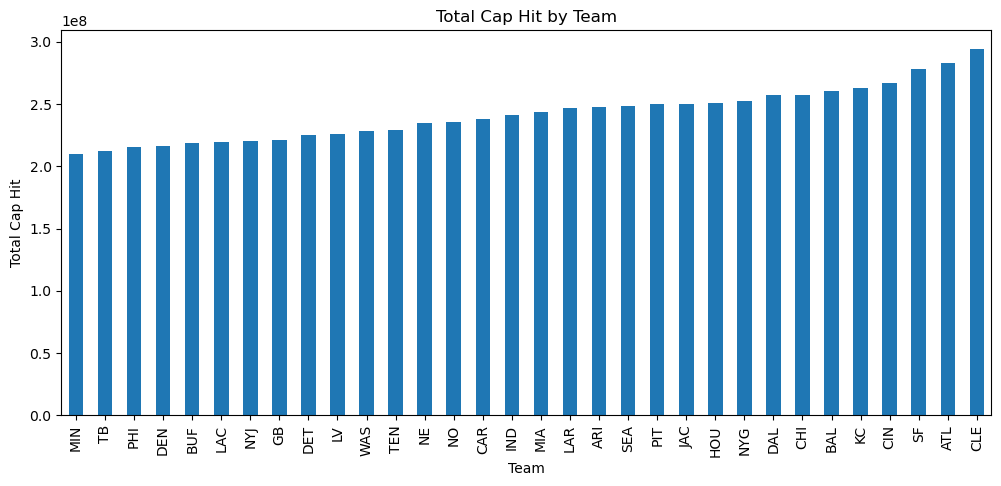

In [45]:
team_salary.plot(kind='bar', figsize=(12, 5))
plt.title('Total Cap Hit by Team')
plt.xlabel('Team')
plt.ylabel('Total Cap Hit')
plt.show()

#### Analysis
- Total cap hit is relatively similar across teams, reflecting the NFL salary cap structure that limits how much teams can spend.
- There is still some variation, with a few teams spending slightly more, which may reflect differences in roster construction or timing of large contracts.
- Teams with higher totals may have more star players or recently signed high-value deals.
- Overall, this suggests that while teams operate under similar financial constraints, they still differ in how aggressively they allocate their cap space.

In [48]:
team_position = df.groupby(['Team', 'Position'])['CapHit'].sum()

team_total = df.groupby('Team')['CapHit'].sum()

percent_alloc = team_position / team_total

percent_alloc = percent_alloc.unstack().fillna(0)

percent_alloc.head()

Position,C,CB,DB,DE,DL,DT,FB,FS,ILB,K,...,OL,OLB,OT,P,QB,RB,SAF,SS,TE,WR
Team,,,,,,,,,,,,,,,,,,,,,
ARI,0.029200,0.059501,0.066332,0.008097,0.013458,0.070173,0.000000,0.000000,0.000000,0.019197,...,0.000000,0.027280,0.088167,0.006466,0.207382,0.068298,0.007679,0.076889,0.025505,0.084574
ATL,0.011699,0.080877,0.016076,0.024753,0.002810,0.136137,0.000000,0.061851,0.000000,0.018555,...,0.006291,0.000000,0.137552,0.013415,0.121889,0.033957,0.020131,0.000000,0.056271,0.086768
BAL,0.017017,0.138736,0.009203,0.007476,0.003060,0.091455,0.019789,0.069204,0.051823,0.022265,...,0.007545,0.000000,0.107366,0.004451,0.135035,0.040440,0.023930,0.000000,0.082786,0.067648
BUF,0.009315,0.094541,0.016023,0.083687,0.007873,0.060986,0.010211,0.000000,0.000000,0.020218,...,0.003656,0.126209,0.095950,0.013029,0.152696,0.025485,0.036262,0.000000,0.062316,0.079332
CAR,0.045877,0.059730,0.003839,0.011320,0.000000,0.093850,0.000000,0.032559,0.014617,0.014019,...,0.000000,0.025177,0.213352,0.011471,0.060389,0.068980,0.037937,0.000000,0.042725,0.137763


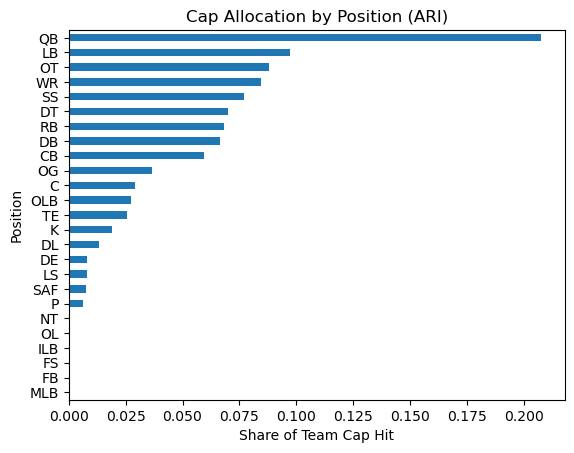

In [50]:
percent_alloc.loc['ARI'].sort_values().plot(kind='barh')
plt.title('Cap Allocation by Position (ARI)')
plt.xlabel('Share of Team Cap Hit')
plt.show()

#### Analysis
- The Cardinals allocate the largest share of their cap to the QB position, indicating a strong investment in their quarterback.
- Offensive positions like OT and WR also receive significant portions, suggesting a focus on supporting the passing game.
- Defensive positions (LB, SS, DT, etc.) receive more moderate and spread-out allocations, indicating a more balanced defensive spending strategy.
- Several positions receive very little cap space, showing that not all roles are prioritized equally.
- Overall, this highlights a top-heavy allocation strategy centered around key offensive positions, especially quarterback.

### Physical Traits vs Salary

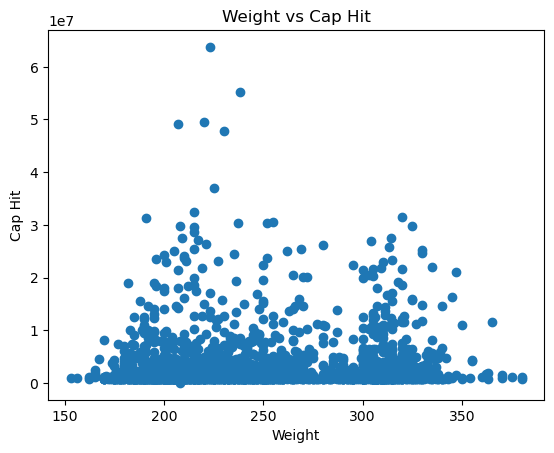

In [54]:
# Weight
plt.scatter(df['Weight'], df['CapHit'])
plt.xlabel('Weight')
plt.ylabel('Cap Hit')
plt.title('Weight vs Cap Hit')
plt.show()

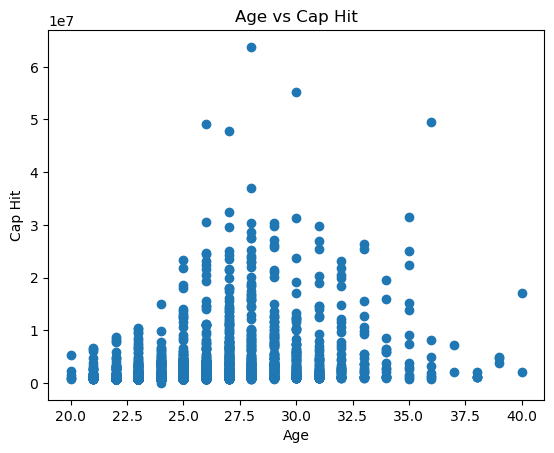

In [56]:
# Age
plt.scatter(df['Age'], df['CapHit'])
plt.xlabel('Age')
plt.ylabel('Cap Hit')
plt.title('Age vs Cap Hit')
plt.show()

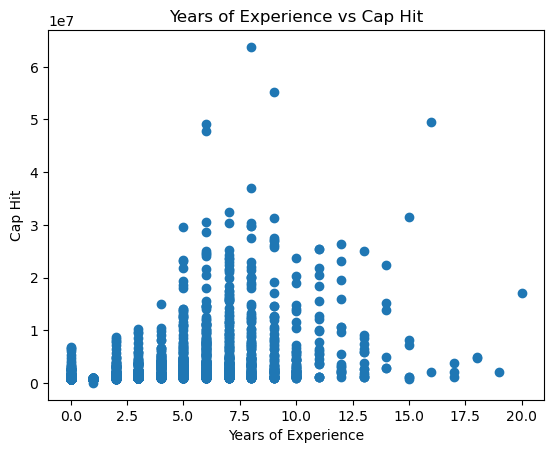

In [58]:
# Years of experience
plt.scatter(df['YrsExp'], df['CapHit'])
plt.xlabel('Years of Experience')
plt.ylabel('Cap Hit')
plt.title('Years of Experience vs Cap Hit')
plt.show()

#### Analysis
- There is little to no clear relationship between weight and cap hit, as players of many different sizes appear across all salary levels.
- Age shows a mild trend where cap hits increase into the mid-to-late 20s, but high salaries are still scattered, indicating variability.
- Years of experience has a clearer pattern: players tend to earn more after gaining several years in the league, with the highest cap hits clustered around mid-career.
- However, all three plots show high variability and outliers, suggesting that factors like position, performance, and contract structure play a much larger role than physical traits alone.

### Top 10 Highest Cap Hits

In [62]:
top10 = df[['Name', 'Team', 'Position', 'Age', 'YrsExp', 'CapHit']].sort_values('CapHit', ascending=False).head(10)

top10

,Name,Team,Position,Age,YrsExp,CapHit
645,Deshaun Watson,CLE,QB,28,8,63774678
733,Dak Prescott,DAL,QB,30,9,55132647
1569,Matt Stafford,LAR,QB,36,16,49500000
53,Kyler Murray,ARI,QB,26,6,49118177
2068,Daniel Jones,NYG,QB,27,6,47855000
1414,Patrick Mahomes,KC,QB,28,8,37008269
226,Lamar Jackson,BAL,QB,27,7,32400000
2577,Trent Williams,SF,OT,35,15,31568542
1774,Tyreek Hill,MIA,WR,30,9,31323750
1663,Maxx Crosby,LV,DE,26,6,30483250


#### Analysis
- The top 10 highest cap hits are dominated by quarterbacks, highlighting the premium value placed on the position.
- These players are mostly in their mid-to-late 20s and early 30s, suggesting that peak earnings occur during prime performance years.
- A few non-QB positions (such as OT, WR, and DE) appear, but far less frequently, reinforcing how uniquely valuable quarterbacks are.
- Overall, this confirms that elite, franchise-level players—especially quarterbacks—command significantly higher salaries than all other positions.

### Average Cap Hit by Team and Position

In [66]:
team_pos_avg = df.groupby(['Team', 'Position'])['CapHit'].mean().unstack()

team_pos_avg.head()

Position,C,CB,DB,DE,DL,DT,FB,FS,ILB,K,...,OL,OLB,OT,P,QB,RB,SAF,SS,TE,WR
Team,,,,,,,,,,,,,,,,,,,,,
ARI,2.408333e+06,1.635845e+06,3.282556e+06,1.001691e+06,1665014.5,2.480476e+06,NaN,NaN,NaN,4750000.0,...,NaN,6750000.0,2.726959e+06,1600000.0,1.710446e+07,2.816556e+06,9.500000e+05,19025000.0,1.051800e+06,1.743883e+06
ATL,3.310181e+06,2.542580e+06,9.097000e+05,1.167276e+06,795000.0,5.502635e+06,NaN,17500000.0,NaN,5250000.0,...,890000.0,NaN,5.559840e+06,1897750.0,8.621786e+06,1.601280e+06,1.898639e+06,NaN,3.184272e+06,1.888473e+06
BAL,2.216452e+06,3.614100e+06,7.991107e+05,9.737500e+05,797166.0,3.403467e+06,5155000.0,18027918.0,13500000.0,5800000.0,...,982710.5,NaN,4.661503e+06,1159458.0,8.794274e+06,2.106944e+06,2.077980e+06,NaN,3.594347e+06,1.468545e+06
BUF,1.018156e+06,2.583486e+06,8.757290e+05,2.032796e+06,860583.0,2.666459e+06,2232334.0,NaN,NaN,4420000.0,...,799333.0,13795500.0,2.621999e+06,1424166.5,1.112709e+07,1.114272e+06,1.981832e+06,NaN,2.724620e+06,1.334086e+06
CAR,5.466500e+06,2.033476e+06,9.150000e+05,8.992220e+05,NaN,2.795722e+06,NaN,7759168.0,3483333.0,1670500.0,...,NaN,6000000.0,5.649386e+06,2733668.0,4.797162e+06,2.348405e+06,1.291555e+06,NaN,2.036388e+06,2.735887e+06


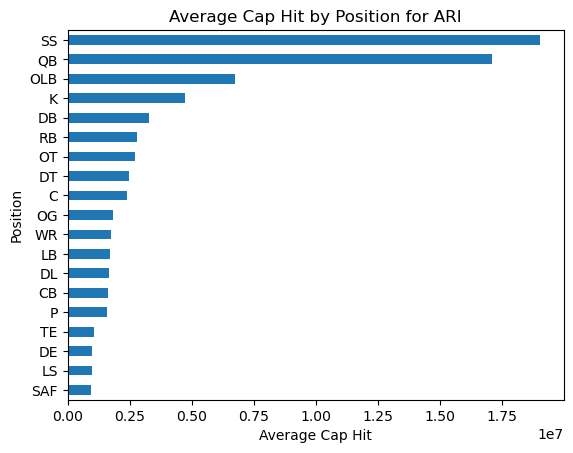

In [68]:
# for one team
team_pos_avg.loc['ARI'].dropna().sort_values().plot(kind='barh')
plt.title('Average Cap Hit by Position for ARI')
plt.xlabel('Average Cap Hit')
plt.show()

#### Analysis
- For the Cardinals, the highest average cap hits are concentrated in positions like SS and QB, indicating significant investment in key impact players.
- Offensive positions such as QB and OL positions still rank highly, reinforcing the importance of protecting and supporting offensive production.
- Many other positions have much lower average cap hits, suggesting depth roles or more evenly distributed contracts among those groups.
- Compared to total allocation, this view highlights which positions have the most highly paid individual players, not just overall spending.
- Overall, the team appears to invest heavily in a few premium positions while maintaining lower average salaries across the rest of the roster.

## Conclusions
- Quarterbacks consistently receive the highest salaries, confirming their importance as the most valuable position in the NFL.
- Salary tends to increase with experience, peaking during mid-career years, though a few elite veterans create noticeable outliers.
- Across teams, total cap spending is relatively similar due to the salary cap, but teams differ in how they allocate that money.
- Team-level analysis shows that some teams concentrate spending on key positions (especially QB), while others distribute cap space more evenly.
- Position-based allocation reveals clear strategic differences, with offensive positions—particularly QB and OL—often prioritized.
- Physical traits like weight and age show weak relationships with salary, indicating that performance, role, and contract value are more important drivers.
- The presence of extreme outliers (high-paid elite players) suggests that averages alone can sometimes be misleading.

Overall, NFL salary structures reflect a combination of league constraints and strategic decision-making, with teams prioritizing key positions differently based on their competitive approach.